## This notebook is used for the course "Medical Imaging for AI" by Group 24. Its contents analyze the dataset, both training and validation splits. They uncover distributional differences, and visualize certain instances for better understanding.

In [1]:
## Necessary packages
from pathlib import Path
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from collections import Counter



In [2]:
#Loading the datasets

# 1. Dataset root

DATA_ROOT = Path("data/SEGTHOR")

# Sanity checks to assess whether dataset exists
assert DATA_ROOT.exists(), f"Dataset not found: {DATA_ROOT.resolve()}"

print(f"Dataset root: {DATA_ROOT.resolve()}\n")


# 2. Show the elements directly inside data/SEGTHOR

print("Elements in data/SEGTHOR:")
for element in sorted(DATA_ROOT.iterdir()):
    element_type = "DIR " if element.is_dir() else "FILE"
    print(f"  [{element_type}] {element.name}")


# 3. Load the spacing information

SPACING_PATH = DATA_ROOT / "spacing.pkl"

with open(SPACING_PATH, "rb") as f:
    spacing = pickle.load(f)

print("\nspacing.pkl:")
print(f"  Type: {type(spacing)}")
print(f"  Number of elements: {len(spacing)}")

print("\nSpacing contents:")
print(spacing)


# 4. Collect all image and ground-truth paths

train_img_paths = sorted((DATA_ROOT / "train" / "img").glob("*.png"))
train_gt_paths  = sorted((DATA_ROOT / "train" / "gt").glob("*.png"))

val_img_paths = sorted((DATA_ROOT / "val" / "img").glob("*.png"))
val_gt_paths  = sorted((DATA_ROOT / "val" / "gt").glob("*.png"))


# 5. Show dataset contents


print("\nDataset contents:")
print(f"  Train images: {len(train_img_paths)}")
print(f"  Train GT:     {len(train_gt_paths)}")
print(f"  Val images:   {len(val_img_paths)}")
print(f"  Val GT:       {len(val_gt_paths)}")


# 6. Create a table containing every PNG in the dataset


all_files = []

for split in ["train", "val"]:
    for data_type in ["img", "gt"]:
        folder = DATA_ROOT / split / data_type

        for path in sorted(folder.glob("*.png")):
            all_files.append({
                "split": split,
                "type": data_type,
                "filename": path.name,
                "path": str(path),
            })

files_df = pd.DataFrame(all_files)

print(f"\nTotal PNG files: {len(files_df)}")

# Display the complete file listing
display(files_df)

Dataset root: C:\Users\bodga\OneDrive\Documents\Documents\University of Amsterdam 2026-2027\Period 1\5204AFMI6Y - Medical Imaging for AI\ai4mi_project\data\SEGTHOR

Elements in data/SEGTHOR:
  [FILE] spacing.pkl
  [DIR ] train
  [DIR ] val

spacing.pkl:
  Type: <class 'dict'>
  Number of elements: 20

Spacing contents:
{'Patient_18': (np.float32(0.976562), np.float32(0.976562), np.float32(2.5)), 'Patient_12': (np.float32(0.9765625), np.float32(0.9765625), np.float32(2.0)), 'Patient_03': (np.float32(0.976562), np.float32(0.976562), np.float32(2.5)), 'Patient_04': (np.float32(0.976562), np.float32(0.976562), np.float32(2.5)), 'Patient_10': (np.float32(0.9765625), np.float32(0.9765625), np.float32(2.0)), 'Patient_06': (np.float32(0.976562), np.float32(0.976562), np.float32(2.5)), 'Patient_08': (np.float32(0.976562), np.float32(0.976562), np.float32(2.5)), 'Patient_05': (np.float32(0.9765625), np.float32(0.9765625), np.float32(2.0)), 'Patient_20': (np.float32(1.367188), np.float32(1.367188

,split,type,filename,path
0,train,img,Patient_02_0000.png,data\SEGTHOR\train\img\Patient_02_0000.png
1,train,img,Patient_02_0001.png,data\SEGTHOR\train\img\Patient_02_0001.png
2,train,img,Patient_02_0002.png,data\SEGTHOR\train\img\Patient_02_0002.png
3,train,img,Patient_02_0003.png,data\SEGTHOR\train\img\Patient_02_0003.png
4,train,img,Patient_02_0004.png,data\SEGTHOR\train\img\Patient_02_0004.png
...,...,...,...,...
7459,val,gt,Patient_19_0185.png,data\SEGTHOR\val\gt\Patient_19_0185.png
7460,val,gt,Patient_19_0186.png,data\SEGTHOR\val\gt\Patient_19_0186.png
7461,val,gt,Patient_19_0187.png,data\SEGTHOR\val\gt\Patient_19_0187.png
7462,val,gt,Patient_19_0188.png,data\SEGTHOR\val\gt\Patient_19_0188.png


### 1. From this we learnt that the voxel sizes are varying between:
| Voxel spacing (mm) | Number of patients |
|---|---:|
| 0.976562 × 0.976562 × 2.5 | 11 |
| 0.9765625 × 0.9765625 × 2.0 | 6 |
| 1.367188 × 1.367188 × 2.5 | 1 |
| 1.269531 × 1.269531 × 2.5 | 1 |
| 0.896484 × 0.896484 × 2.5 | 1 |
| **Total** | **20** |
### 2. Dataset contents

| Split | Images | Ground Truth | Total PNG files |
|---|---:|---:|---:|
| Train | 2,817 | 2,817 | 5,634 |
| Validation | 915 | 915 | 1,830 |
| **Total** | **3,732** | **3,732** | **7,464** |

### 3. Key observations

- The dataset contains **20 patients**.
- The PNG dataset consists of **3,732 image slices** and **3,732 corresponding ground-truth slices**.
- There are **2,817 training slices** and **915 validation slices**.
- The train/validation split contains approximately **75.5% training** and **24.5% validation** slices.
- The in-plane voxel spacing is generally around **0.98 × 0.98 mm**, while the slice thickness is either **2.0 mm or 2.5 mm** for most patients.
- Therefore, the original CT data has **anisotropic voxel spacing**, with substantially larger spacing between slices than within each axial slice.
- The `spacing.pkl` file is important for analyses involving **3D physical distances**, because voxel counts alone do not directly correspond to distances in millimetres.

In [3]:
# Next, we visualize some slices with their ground truth

def show_slice(img_path, gt_path, figsize=(12, 5)):
    """
    Display a CT slice and its corresponding ground-truth segmentation.
    """
    img = Image.open(img_path)
    gt = Image.open(gt_path)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # CT image
    axes[0].imshow(img, cmap="gray")
    axes[0].set_title("CT image")
    axes[0].axis("off")

    # Ground truth
    axes[1].imshow(gt)
    axes[1].set_title("Ground truth")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

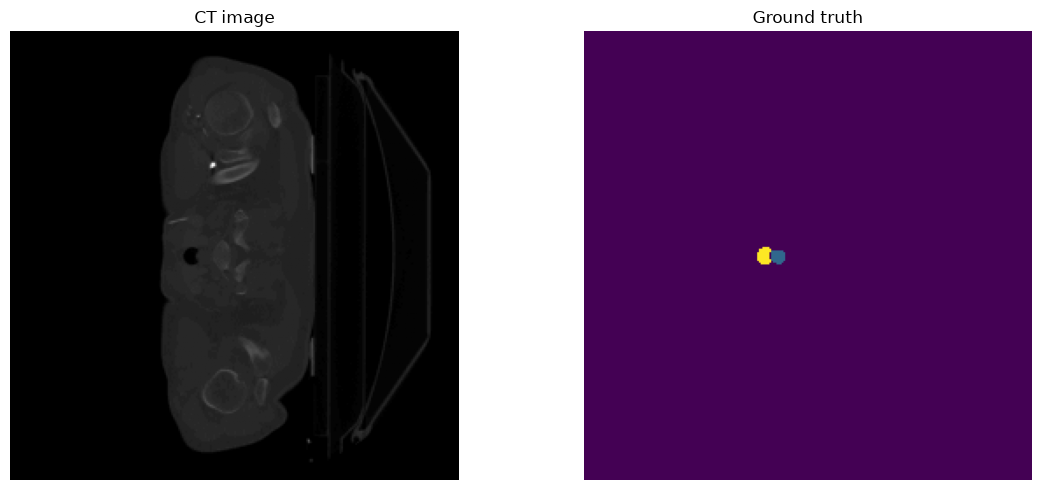

In [41]:
show_slice(
    train_img_paths[200],
    train_gt_paths[200]
)

In [5]:
gt = np.array(Image.open(train_gt_paths[100]))

print("Shape:", gt.shape)
print("Dtype:", gt.dtype)
print("Unique values:", np.unique(gt))

Shape: (256, 256)
Dtype: uint8
Unique values: [ 0 63]


### The structure of the GT masks:

| Raw pixel value | Encoded label | Anatomical structure |
|---:|---:|---|
| 0 | 0 | Background |
| 63 | 1 | Esophagus |
| 126 | 2 | Heart |
| 189 | 3 | Trachea |
| 252 | 4 | Aorta |

In [6]:
# Next up, label distributions

# Raw pixel values used in the GT PNGs
label_values = {
    0: 0,      # background
    63: 1,     # esophagus
    126: 2,    # heart
    189: 3,    # trachea
    252: 4     # aorta
}

class_names = {
    0: "Background",
    1: "Esophagus",
    2: "Heart",
    3: "Trachea",
    4: "Aorta"
}


def count_labels(gt_paths):
    """
    Count raw GT pixel values across a list of PNG files.
    """
    counts = Counter()

    for path in gt_paths:
        gt = np.array(Image.open(path))
        values, pixel_counts = np.unique(gt, return_counts=True)

        for value, count in zip(values, pixel_counts):
            counts[int(value)] += int(count)

    return counts


# Count pixels
train_counts_raw = count_labels(train_gt_paths)
val_counts_raw = count_labels(val_gt_paths)

# Combine train + validation
all_gt_paths = train_gt_paths + val_gt_paths
all_counts_raw = count_labels(all_gt_paths)


# Convert raw pixel values to encoded labels
def make_distribution_df(counts):
    rows = []

    total_pixels = sum(counts.values())

    for raw_value, encoded_label in label_values.items():
        count = counts.get(raw_value, 0)

        rows.append({
            "Raw pixel value": raw_value,
            "Encoded label": encoded_label,
            "Class": class_names[encoded_label],
            "Pixel count": count,
            "Percentage": 100 * count / total_pixels
        })


    return pd.DataFrame(rows)


train_distribution = make_distribution_df(train_counts_raw)
val_distribution = make_distribution_df(val_counts_raw)
all_distribution = make_distribution_df(all_counts_raw)

# Calculate foreground-only distribution
foreground_distribution = all_distribution[
    all_distribution["Encoded label"] != 0
].copy()

foreground_total = foreground_distribution["Pixel count"].sum()

foreground_distribution["Percentage"] = (
    100 * foreground_distribution["Pixel count"] / foreground_total
)

display(foreground_distribution)

display(all_distribution)

,Raw pixel value,Encoded label,Class,Pixel count,Percentage
1,63,1,Esophagus,566949,22.192642
2,126,2,Heart,1873763,73.346548
3,189,3,Trachea,91501,3.581714
4,252,4,Aorta,22458,0.879096


,Raw pixel value,Encoded label,Class,Pixel count,Percentage
0,0,0,Background,242025681,98.955488
1,63,1,Esophagus,566949,0.231805
2,126,2,Heart,1873763,0.766113
3,189,3,Trachea,91501,0.037411
4,252,4,Aorta,22458,0.009182


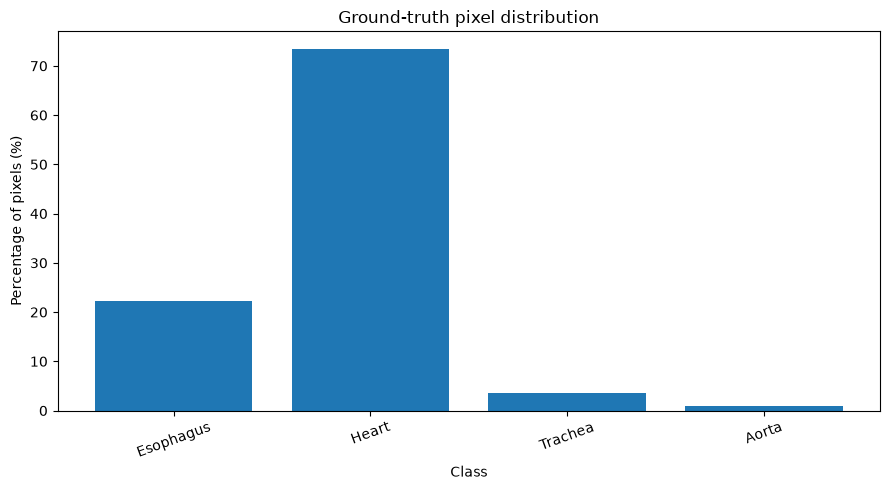

In [7]:
plt.figure(figsize=(9, 5))

plt.bar(
    foreground_distribution["Class"],
    foreground_distribution["Percentage"]
)

plt.ylabel("Percentage of pixels (%)")
plt.xlabel("Class")
plt.title("Ground-truth pixel distribution")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

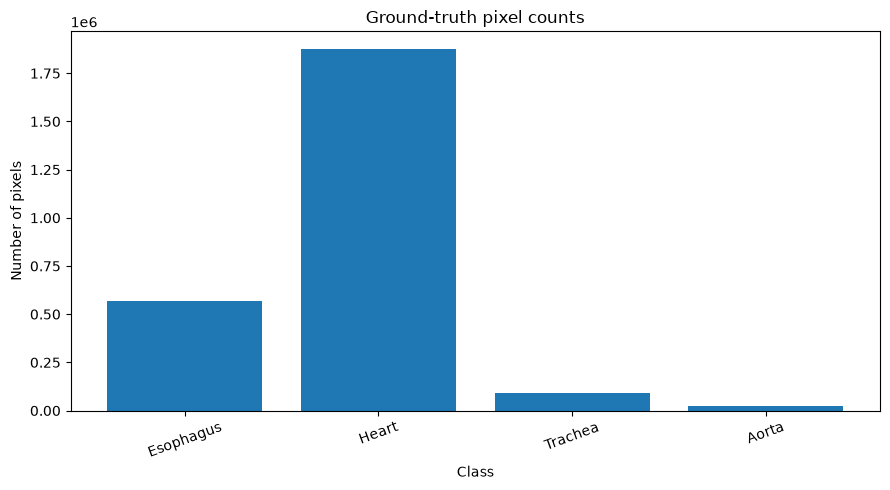

In [8]:
plt.figure(figsize=(9, 5))

plt.bar(
    foreground_distribution["Class"],
    foreground_distribution["Pixel count"]
)

plt.ylabel("Number of pixels")
plt.xlabel("Class")
plt.title("Ground-truth pixel counts")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### This analysis indicates that the 2D slices derived from the NIfTI files dont have any pixel indicating label 4, the aorta. Upon this, we do additional evaluation on the NIfTI dataset, to explore whether the label is present there and lost during the preprocessing, or not present at all.

In [9]:
import nibabel as nib
import numpy as np
import pandas as pd
from pathlib import Path

RAW_ROOT = Path("data/segthor_part1/train")

results = []

for patient_dir in sorted(RAW_ROOT.iterdir()):
    if not patient_dir.is_dir():
        continue

    gt_path = patient_dir / "GT.nii.gz"

    if not gt_path.exists():
        print(f"WARNING: no GT found for {patient_dir.name}")
        continue

    gt = np.asarray(nib.load(str(gt_path)).dataobj)

    unique_labels = np.unique(gt)

    results.append({
        "Patient": patient_dir.name,
        "Shape": gt.shape,
        "Unique labels": list(unique_labels),
        "Has esophagus (1)": 1 in unique_labels,
        "Has heart (2)": 2 in unique_labels,
        "Has trachea (3)": 3 in unique_labels,
        "Has aorta (4)": 4 in unique_labels,
    })

df_labels = pd.DataFrame(results)

display(df_labels)

,Patient,Shape,Unique labels,Has esophagus (1),Has heart (2),Has trachea (3),Has aorta (4)
0,Patient_01,"(512, 512, 229)","[0, 1, 2, 3]",True,True,True,False
1,Patient_02,"(512, 512, 246)","[0, 1, 2, 3]",True,True,True,False
2,Patient_03,"(512, 512, 147)","[0, 1, 2, 3]",True,True,True,False
3,Patient_04,"(512, 512, 158)","[0, 1, 2, 3]",True,True,True,False
4,Patient_05,"(512, 512, 284)","[0, 1, 2, 3]",True,True,True,False
5,Patient_06,"(512, 512, 199)","[0, 1, 2, 3]",True,True,True,False
6,Patient_07,"(512, 512, 179)","[0, 1, 2, 3, 4]",True,True,True,True
7,Patient_08,"(512, 512, 171)","[0, 1, 2, 3]",True,True,True,False
8,Patient_09,"(512, 512, 154)","[0, 1, 2, 3]",True,True,True,False
9,Patient_10,"(512, 512, 163)","[0, 1, 2, 3]",True,True,True,False


### We have thus derived, that the aorta as a label is completely missing from the dataset

In [10]:
# Next, we look at the structures of the GT masks

# Raw GT values
label_values = {
    "Esophagus": 63,
    "Heart": 126,
    "Trachea": 189,
    "Aorta": 252,
}

slice_results = []

for gt_path in train_gt_paths + val_gt_paths:
    gt = np.array(Image.open(gt_path))

    row = {
        "filename": gt_path.name,
        "patient": gt_path.name.split("_")[0] + "_" + gt_path.name.split("_")[1],
        "slice": int(gt_path.stem.split("_")[-1]),
    }

    for structure, value in label_values.items():
        row[structure] = np.any(gt == value)

    slice_results.append(row)

slice_df = pd.DataFrame(slice_results)

display(slice_df.head())

,filename,patient,slice,Esophagus,Heart,Trachea,Aorta
0,Patient_02_0000.png,Patient_02,0,False,False,False,False
1,Patient_02_0001.png,Patient_02,1,False,False,False,False
2,Patient_02_0002.png,Patient_02,2,False,False,False,False
3,Patient_02_0003.png,Patient_02,3,False,False,False,False
4,Patient_02_0004.png,Patient_02,4,False,False,False,False


In [11]:
presence_counts = slice_df[
    ["Esophagus", "Heart", "Trachea", "Aorta"]
].sum()

display(presence_counts.to_frame("Number of slices"))

presence_percentage = (
    slice_df[["Esophagus", "Heart", "Trachea", "Aorta"]].mean() * 100
)

display(
    presence_percentage
    .to_frame("Percentage of slices")
    .round(2)
)

,Number of slices
Esophagus,2355
Heart,838
Trachea,1044
Aorta,113


,Percentage of slices
Esophagus,63.10
Heart,22.45
Trachea,27.97
Aorta,3.03


In [12]:
area_results = []

for gt_path in train_gt_paths + val_gt_paths:
    gt = np.array(Image.open(gt_path))

    row = {
        "filename": gt_path.name,
        "patient": gt_path.name.split("_")[0] + "_" + gt_path.name.split("_")[1],
        "slice": int(gt_path.stem.split("_")[-1]),
    }

    for structure, value in label_values.items():
        row[structure] = np.sum(gt == value)

    area_results.append(row)

area_df = pd.DataFrame(area_results)

display(area_df.head())

,filename,patient,slice,Esophagus,Heart,Trachea,Aorta
0,Patient_02_0000.png,Patient_02,0,0,0,0,0
1,Patient_02_0001.png,Patient_02,1,0,0,0,0
2,Patient_02_0002.png,Patient_02,2,0,0,0,0
3,Patient_02_0003.png,Patient_02,3,0,0,0,0
4,Patient_02_0004.png,Patient_02,4,0,0,0,0


In [13]:
patient_id = "Patient_01"

patient_area = area_df[
    area_df["patient"] == patient_id
].sort_values("slice")

display(patient_area)

,filename,patient,slice,Esophagus,Heart,Trachea,Aorta
2817,Patient_01_0000.png,Patient_01,0,0,0,0,0
2818,Patient_01_0001.png,Patient_01,1,0,0,0,0
2819,Patient_01_0002.png,Patient_01,2,0,0,0,0
2820,Patient_01_0003.png,Patient_01,3,0,0,0,0
2821,Patient_01_0004.png,Patient_01,4,0,0,0,0
...,...,...,...,...,...,...,...
3041,Patient_01_0224.png,Patient_01,224,0,0,0,0
3042,Patient_01_0225.png,Patient_01,225,0,0,0,0
3043,Patient_01_0226.png,Patient_01,226,0,0,0,0
3044,Patient_01_0227.png,Patient_01,227,0,0,0,0


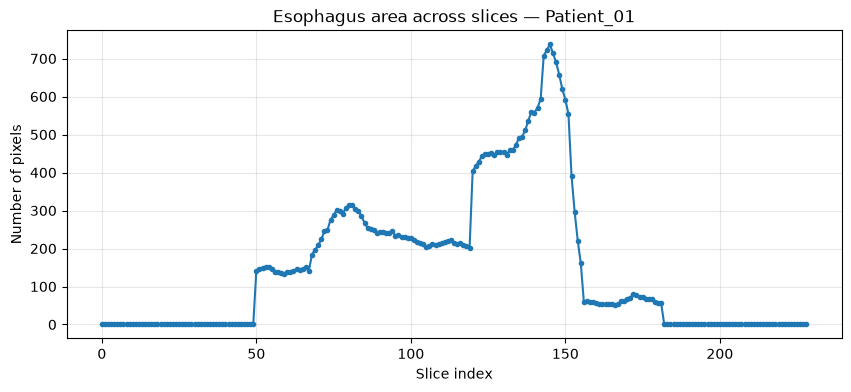

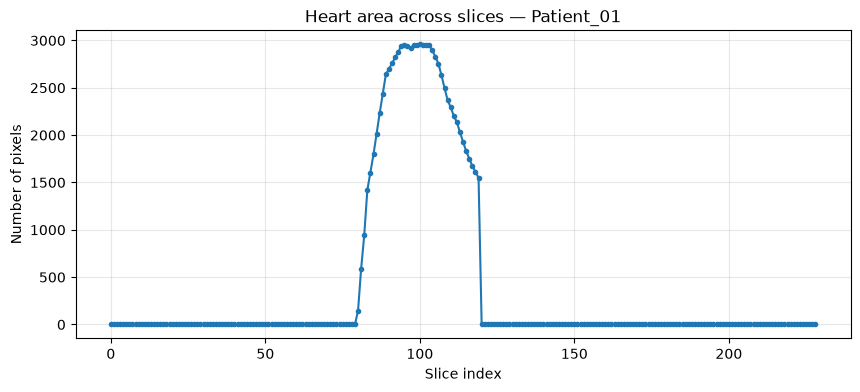

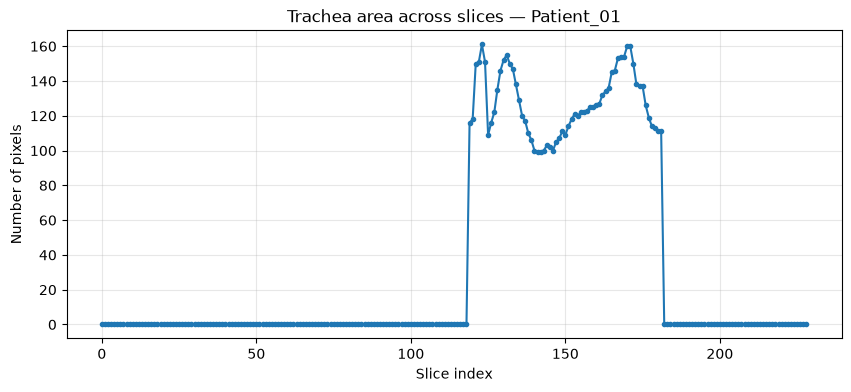

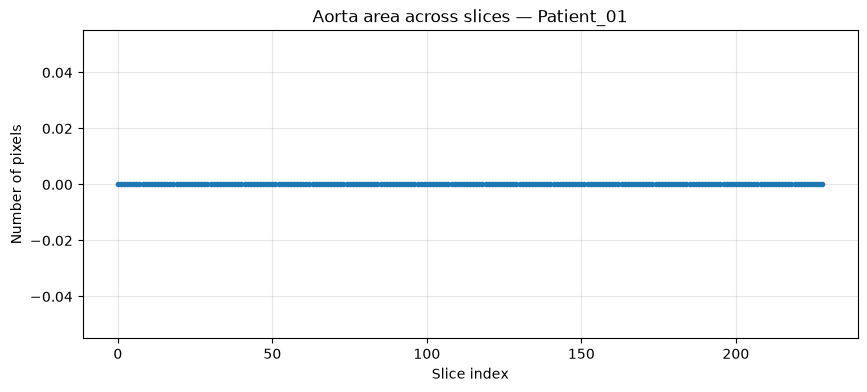

In [14]:
import matplotlib.pyplot as plt

structures = ["Esophagus", "Heart", "Trachea", "Aorta"]

for structure in structures:
    plt.figure(figsize=(10, 4))

    plt.plot(
        patient_area["slice"],
        patient_area[structure],
        marker="."
    )

    plt.xlabel("Slice index")
    plt.ylabel("Number of pixels")
    plt.title(f"{structure} area across slices — {patient_id}")
    plt.grid(alpha=0.3)
    plt.show()

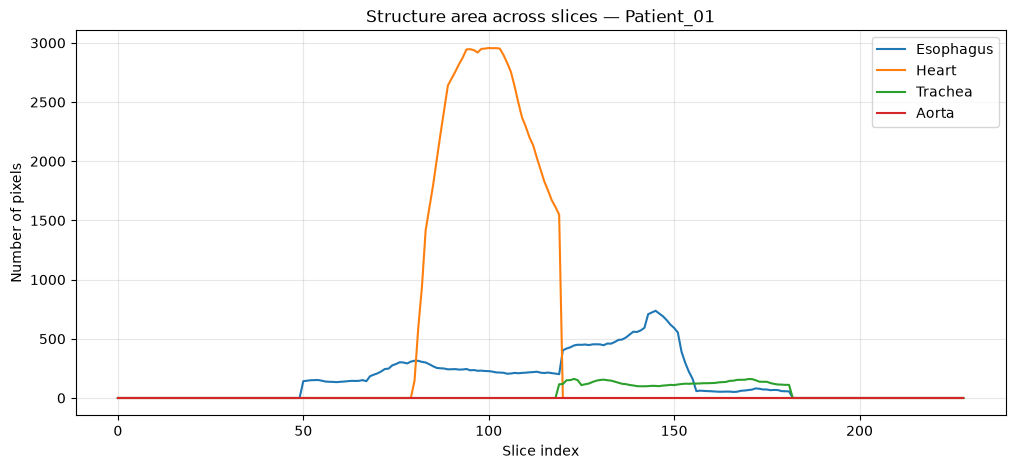

In [15]:
plt.figure(figsize=(12, 5))

for structure in structures:
    plt.plot(
        patient_area["slice"],
        patient_area[structure],
        label=structure
    )

plt.xlabel("Slice index")
plt.ylabel("Number of pixels")
plt.title(f"Structure area across slices — {patient_id}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [16]:
range_results = []

for patient in area_df["patient"].unique():

    patient_data = area_df[
        area_df["patient"] == patient
    ].sort_values("slice")

    for structure in structures:

        present = patient_data[
            patient_data[structure] > 0
        ]

        if len(present) == 0:
            first_slice = None
            last_slice = None
            number_of_slices = 0
        else:
            first_slice = present["slice"].min()
            last_slice = present["slice"].max()
            number_of_slices = len(present)

        range_results.append({
            "patient": patient,
            "structure": structure,
            "first slice": first_slice,
            "last slice": last_slice,
            "number of slices": number_of_slices,
        })

range_df = pd.DataFrame(range_results)

display(range_df)

,patient,structure,first slice,last slice,number of slices
0,Patient_02,Esophagus,81.0,202.0,122
1,Patient_02,Heart,112.0,148.0,37
2,Patient_02,Trachea,155.0,202.0,48
3,Patient_02,Aorta,NaN,NaN,0
4,Patient_03,Esophagus,6.0,115.0,110
...,...,...,...,...,...
75,Patient_17,Aorta,NaN,NaN,0
76,Patient_19,Esophagus,21.0,138.0,118
77,Patient_19,Heart,32.0,73.0,42
78,Patient_19,Trachea,84.0,138.0,55


In [17]:


# Raw PNG label values
label_values = {
    "Esophagus": 63,
    "Heart": 126,
    "Trachea": 189,
    "Aorta": 252,
}

# Use all available GT slices
gt_paths = train_gt_paths + val_gt_paths

# Create one 256x256 accumulator for each structure
heatmaps = {
    structure: np.zeros((256, 256), dtype=np.int32)
    for structure in label_values
}

# Count how often each pixel location belongs to each structure
for gt_path in gt_paths:
    gt = np.array(Image.open(gt_path))

    for structure, value in label_values.items():
        heatmaps[structure] += (gt == value)

# Convert counts to percentage of slices
for structure in heatmaps:
    heatmaps[structure] = (
        heatmaps[structure] / len(gt_paths) * 100
    )

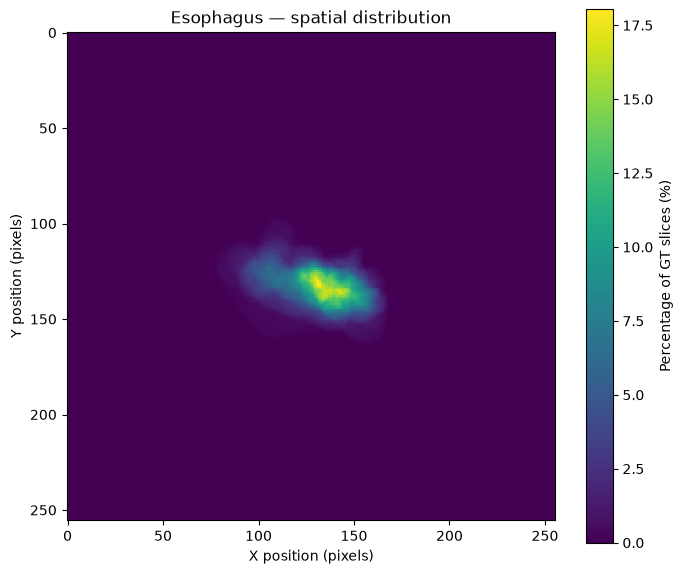

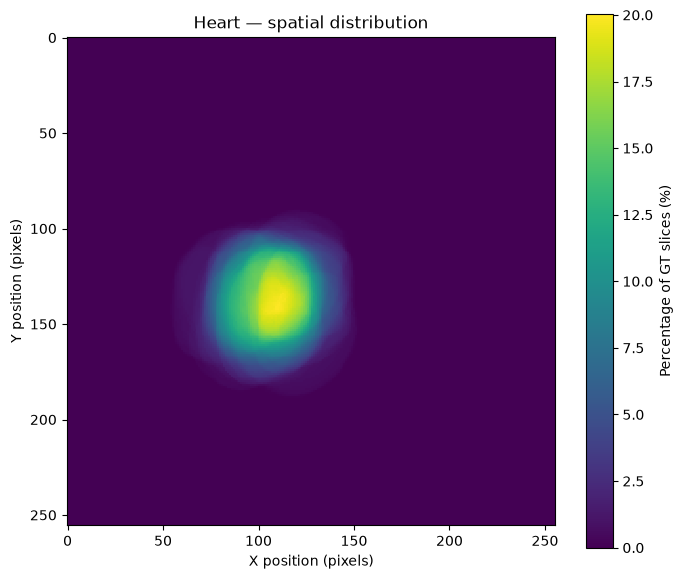

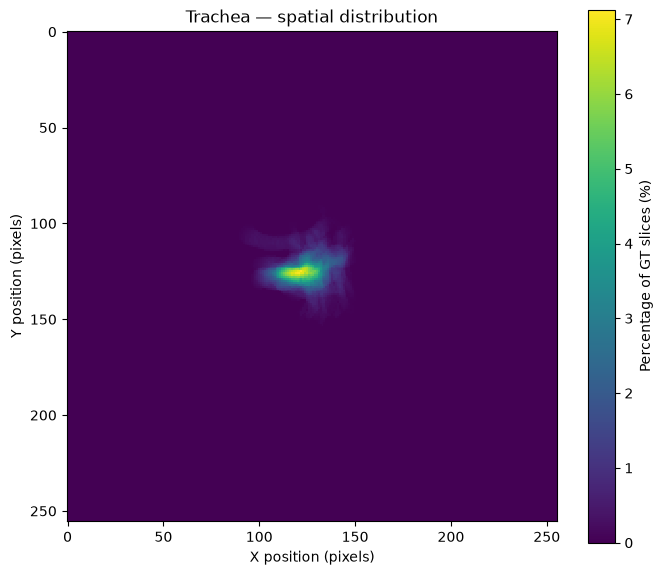

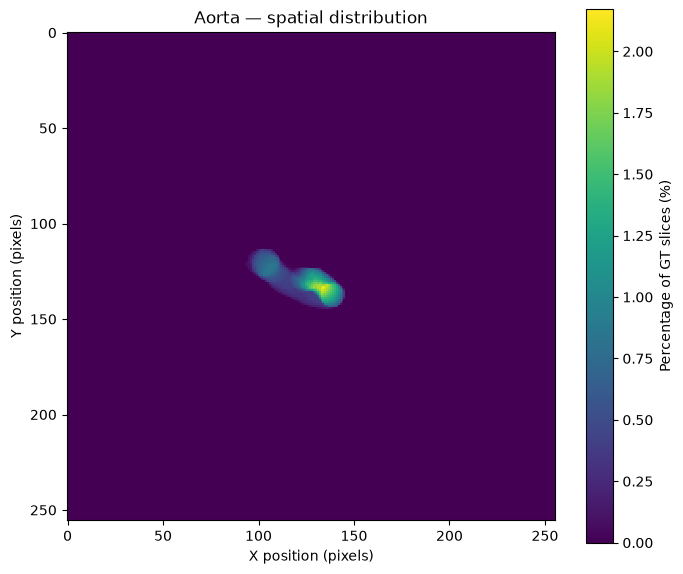

In [18]:
for structure, heatmap in heatmaps.items():

    plt.figure(figsize=(7, 6))

    plt.imshow(
        heatmap,
        interpolation="nearest"
    )

    plt.title(f"{structure} — spatial distribution")
    plt.xlabel("X position (pixels)")
    plt.ylabel("Y position (pixels)")

    plt.colorbar(
        label="Percentage of GT slices (%)"
    )

    plt.tight_layout()
    plt.show()

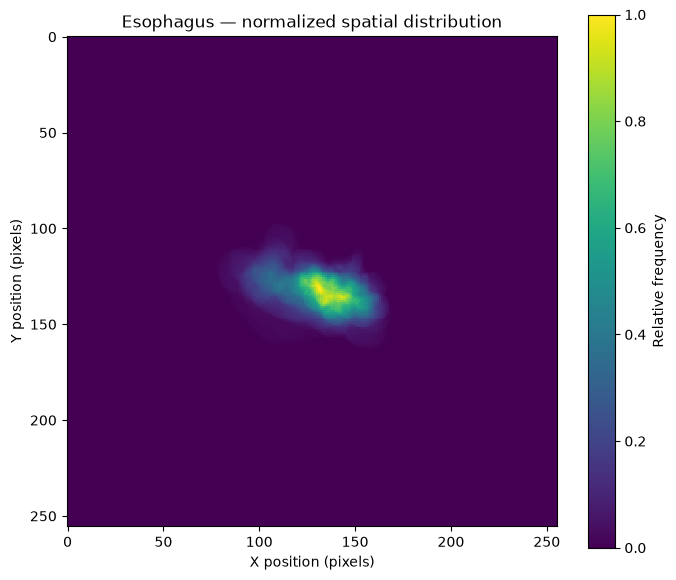

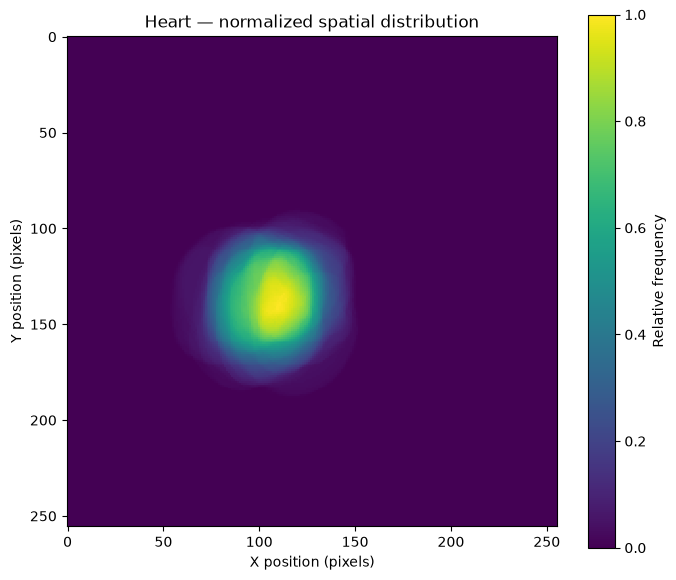

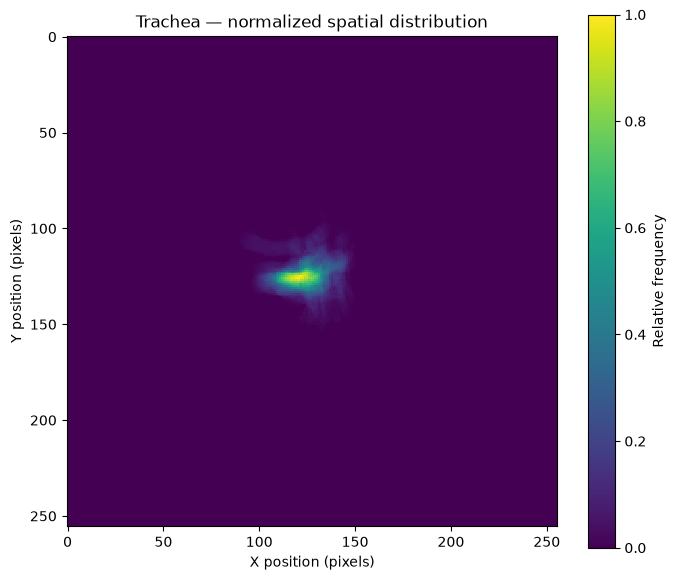

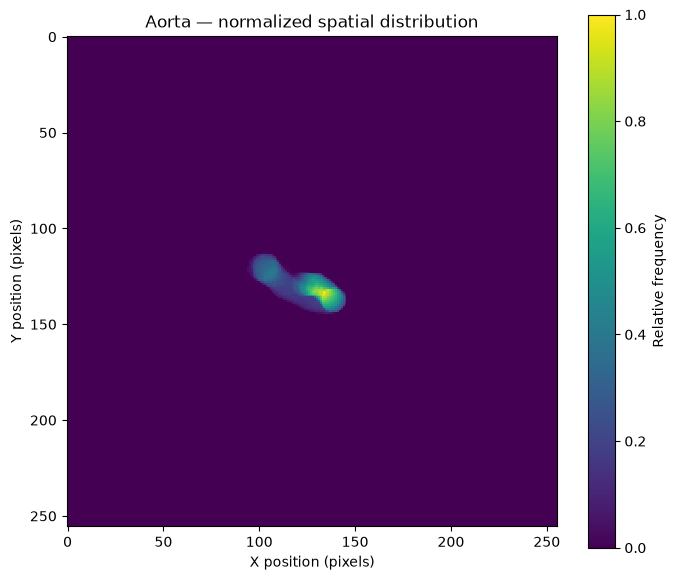

In [19]:
for structure, heatmap in heatmaps.items():

    max_value = heatmap.max()

    if max_value == 0:
        print(f"{structure}: no pixels found")
        continue

    normalized = heatmap / max_value

    plt.figure(figsize=(7, 6))

    plt.imshow(
        normalized,
        interpolation="nearest",
        vmin=0,
        vmax=1
    )

    plt.title(f"{structure} — normalized spatial distribution")
    plt.xlabel("X position (pixels)")
    plt.ylabel("Y position (pixels)")

    plt.colorbar(
        label="Relative frequency"
    )

    plt.tight_layout()
    plt.show()

### As seen, Patient 7 is the only patient with pixels corresponding to the aorta, so we investigate this patient further

In [22]:
import nibabel as nib
import numpy as np
from pathlib import Path

gt_path = Path("data/segthor_part1/train/Patient_07/GT.nii.gz")

gt7 = np.asarray(
    nib.load(str(gt_path)).dataobj
)

print("Shape:", gt7.shape)
print("Unique labels:", np.unique(gt7))

for label in np.unique(gt7):
    print(
        f"Label {label}: {(gt7 == label).sum():,} voxels"
    )

Shape: (512, 512, 179)
Unique labels: [0 1 2 3 4]
Label 0: 46,427,909 voxels
Label 1: 25,373 voxels
Label 2: 365,861 voxels
Label 3: 14,777 voxels
Label 4: 89,856 voxels


In [23]:
aorta_voxels = np.sum(gt7 == 4, axis=(0, 1))
aorta_slices = np.where(aorta_voxels > 0)[0]

print("Aorta appears on", len(aorta_slices), "slices")
print("First slice:", aorta_slices.min())
print("Last slice:", aorta_slices.max())

Aorta appears on 113 slices
First slice: 26
Last slice: 138


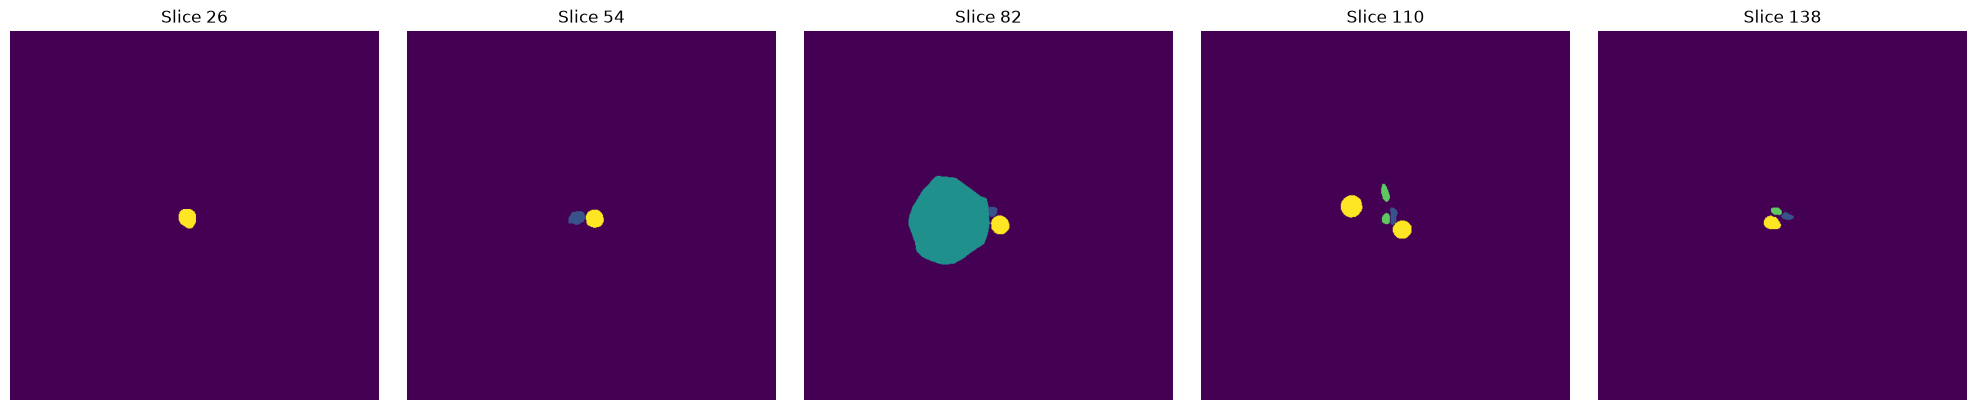

In [24]:
import matplotlib.pyplot as plt

# Pick several slices through the aorta
selected_slices = [
    aorta_slices[0],
    aorta_slices[len(aorta_slices)//4],
    aorta_slices[len(aorta_slices)//2],
    aorta_slices[3*len(aorta_slices)//4],
    aorta_slices[-1],
]

fig, axes = plt.subplots(
    1, len(selected_slices),
    figsize=(20, 4)
)

for ax, z in zip(axes, selected_slices):
    ax.imshow(gt7[:, :, z])
    ax.set_title(f"Slice {z}")
    ax.axis("off")

plt.tight_layout()
plt.show()

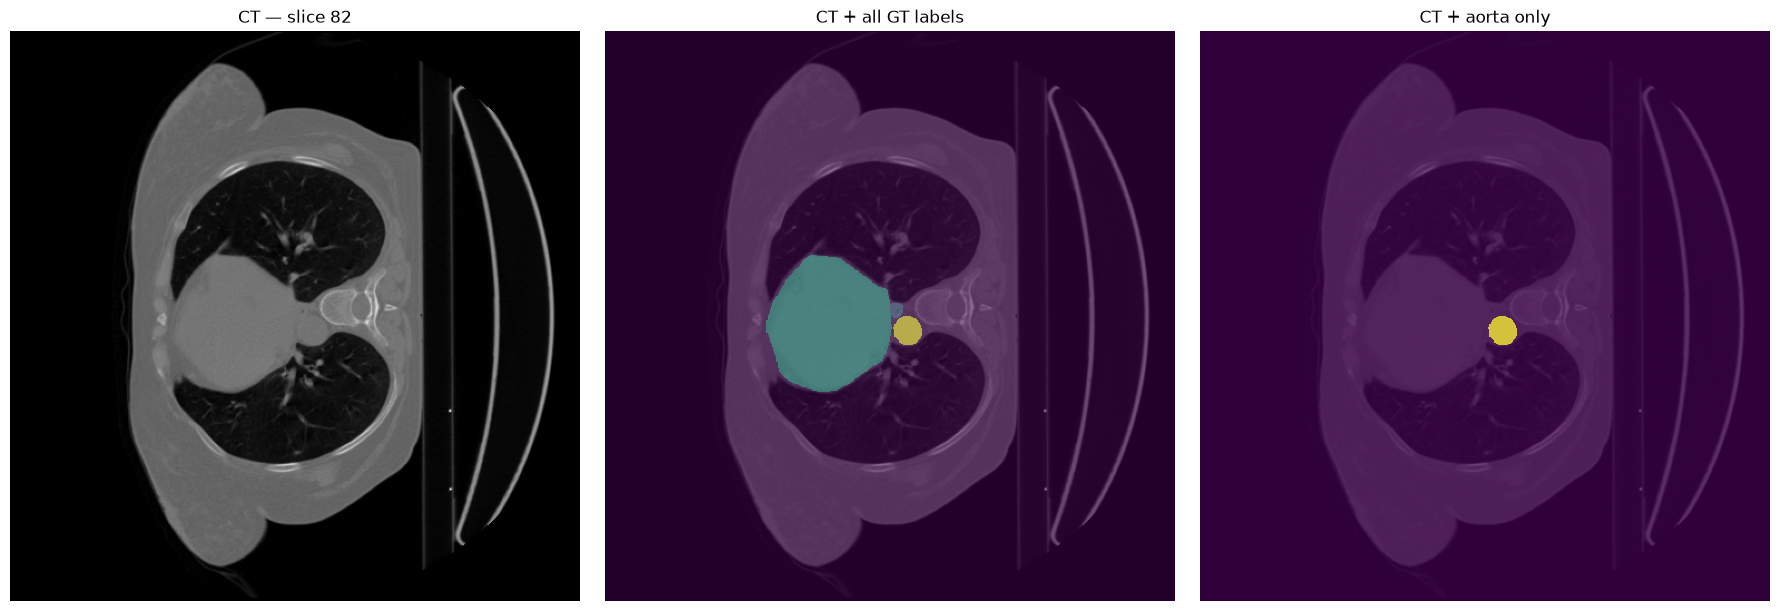

In [25]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

patient = "Patient_07"

patient_dir = Path("data/segthor_part1/train") / patient

ct = np.asarray(
    nib.load(str(patient_dir / f"{patient}.nii.gz")).dataobj
)

gt7 = np.asarray(
    nib.load(str(patient_dir / "GT.nii.gz")).dataobj
)

# Choose the middle slice containing the aorta
z = aorta_slices[len(aorta_slices) // 2]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# CT
axes[0].imshow(ct[:, :, z], cmap="gray")
axes[0].set_title(f"CT — slice {z}")
axes[0].axis("off")

# Full GT
axes[1].imshow(ct[:, :, z], cmap="gray")
axes[1].imshow(
    gt7[:, :, z],
    alpha=0.5,
    interpolation="nearest"
)
axes[1].set_title("CT + all GT labels")
axes[1].axis("off")

# Aorta only
axes[2].imshow(ct[:, :, z], cmap="gray")
axes[2].imshow(
    gt7[:, :, z] == 4,
    alpha=0.7,
    interpolation="nearest"
)
axes[2].set_title("CT + aorta only")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [26]:
from scipy.ndimage import center_of_mass

# Use the middle aorta-containing slice
z = aorta_slices[len(aorta_slices) // 2]

slice_gt = gt7[:, :, z]

print(f"Slice: {z}")

for label, name in [
    (1, "Esophagus"),
    (2, "Heart"),
    (3, "Trachea"),
    (4, "Aorta"),
]:
    mask = slice_gt == label

    if mask.any():
        cy, cx = center_of_mass(mask)
        print(
            f"{name:10s} | "
            f"area = {mask.sum():5d} px | "
            f"centroid = ({cx:.1f}, {cy:.1f})"
        )

Slice: 82
Esophagus  | area =   143 px | centroid = (261.4, 249.9)
Heart      | area = 10348 px | centroid = (200.4, 263.3)
Aorta      | area =   526 px | centroid = (271.6, 268.6)


In [27]:
from scipy.spatial.distance import euclidean

heart_centroid = center_of_mass(slice_gt == 2)
aorta_centroid = center_of_mass(slice_gt == 4)

distance = euclidean(heart_centroid, aorta_centroid)

print(f"Heart–aorta centroid distance: {distance:.1f} pixels")

Heart–aorta centroid distance: 71.4 pixels


In [28]:
relationship = []

for z in aorta_slices:

    slice_gt = gt7[:, :, z]

    heart_mask = slice_gt == 2
    aorta_mask = slice_gt == 4

    if heart_mask.any() and aorta_mask.any():

        heart_y, heart_x = center_of_mass(heart_mask)
        aorta_y, aorta_x = center_of_mass(aorta_mask)

        relationship.append({
            "slice": z,
            "heart_x": heart_x,
            "heart_y": heart_y,
            "aorta_x": aorta_x,
            "aorta_y": aorta_y,
            "distance": np.sqrt(
                (heart_x - aorta_x)**2 +
                (heart_y - aorta_y)**2
            )
        })

relationship_df = pd.DataFrame(relationship)

display(relationship_df.head())

,slice,heart_x,heart_y,aorta_x,aorta_y,distance
0,55,180.430070,313.597902,260.414980,259.904858,96.335501
1,56,199.095452,295.860752,261.126273,259.826884,71.737455
2,57,196.216867,296.209805,261.628866,259.816495,74.854543
3,58,193.567335,296.631805,261.898374,260.313008,77.383369
4,59,193.911635,293.146411,262.050710,260.789047,75.431642


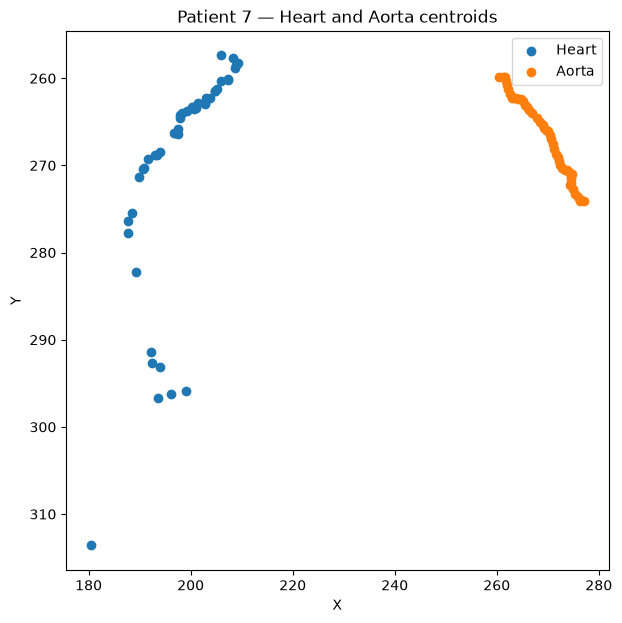

In [29]:
plt.figure(figsize=(7, 7))

plt.scatter(
    relationship_df["heart_x"],
    relationship_df["heart_y"],
    label="Heart"
)

plt.scatter(
    relationship_df["aorta_x"],
    relationship_df["aorta_y"],
    label="Aorta"
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Patient 7 — Heart and Aorta centroids")
plt.legend()
plt.gca().invert_yaxis()
plt.show()

### Now, we check where the heart is in the other 19 patients. Our hypothesis is that the aorta was mislabeled as the heart in their case

In [30]:
from scipy.ndimage import label

heart_components = []

for gt_path in train_gt_paths + val_gt_paths:

    gt = np.array(Image.open(gt_path))

    # Heart = raw value 126
    heart_mask = gt == 126

    labeled, n_components = label(heart_mask)

    heart_components.append({
        "filename": gt_path.name,
        "patient": gt_path.name.split("_")[0] + "_" + gt_path.name.split("_")[1],
        "slice": int(gt_path.stem.split("_")[-1]),
        "heart_components": n_components
    })

heart_components_df = pd.DataFrame(heart_components)

display(heart_components_df.head())

,filename,patient,slice,heart_components
0,Patient_02_0000.png,Patient_02,0,0
1,Patient_02_0001.png,Patient_02,1,0
2,Patient_02_0002.png,Patient_02,2,0
3,Patient_02_0003.png,Patient_02,3,0
4,Patient_02_0004.png,Patient_02,4,0


In [31]:
print(
    heart_components_df["heart_components"]
    .value_counts()
    .sort_index()
)

heart_components
0    2894
1     838
Name: count, dtype: int64


In [32]:
multiple_heart = heart_components_df[
    heart_components_df["heart_components"] > 1
]

print("Slices with multiple heart components:",
      len(multiple_heart))

display(multiple_heart.head(20))

Slices with multiple heart components: 0


,filename,patient,slice,heart_components


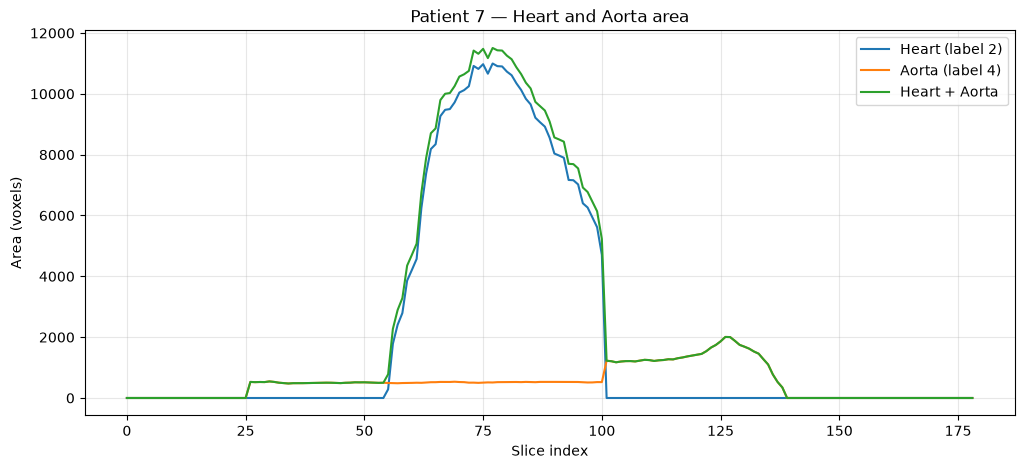

In [33]:
heart_area = np.sum(gt7 == 2, axis=(0, 1))
aorta_area = np.sum(gt7 == 4, axis=(0, 1))
heart_aorta_area = np.sum(
    (gt7 == 2) | (gt7 == 4),
    axis=(0, 1)
)

plt.figure(figsize=(12, 5))

plt.plot(heart_area, label="Heart (label 2)")
plt.plot(aorta_area, label="Aorta (label 4)")
plt.plot(
    heart_aorta_area,
    label="Heart + Aorta"
)

plt.xlabel("Slice index")
plt.ylabel("Area (voxels)")
plt.title("Patient 7 — Heart and Aorta area")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [34]:
combined_area = heart_area + aorta_area

# Find slices where both structures have a reasonable amount of pixels
candidate_slices = np.where(
    (heart_area > 1000) &
    (aorta_area > 100)
)[0]

print("Candidate slices:")
print(candidate_slices)

Candidate slices:
[ 56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73
  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91
  92  93  94  95  96  97  98  99 100]


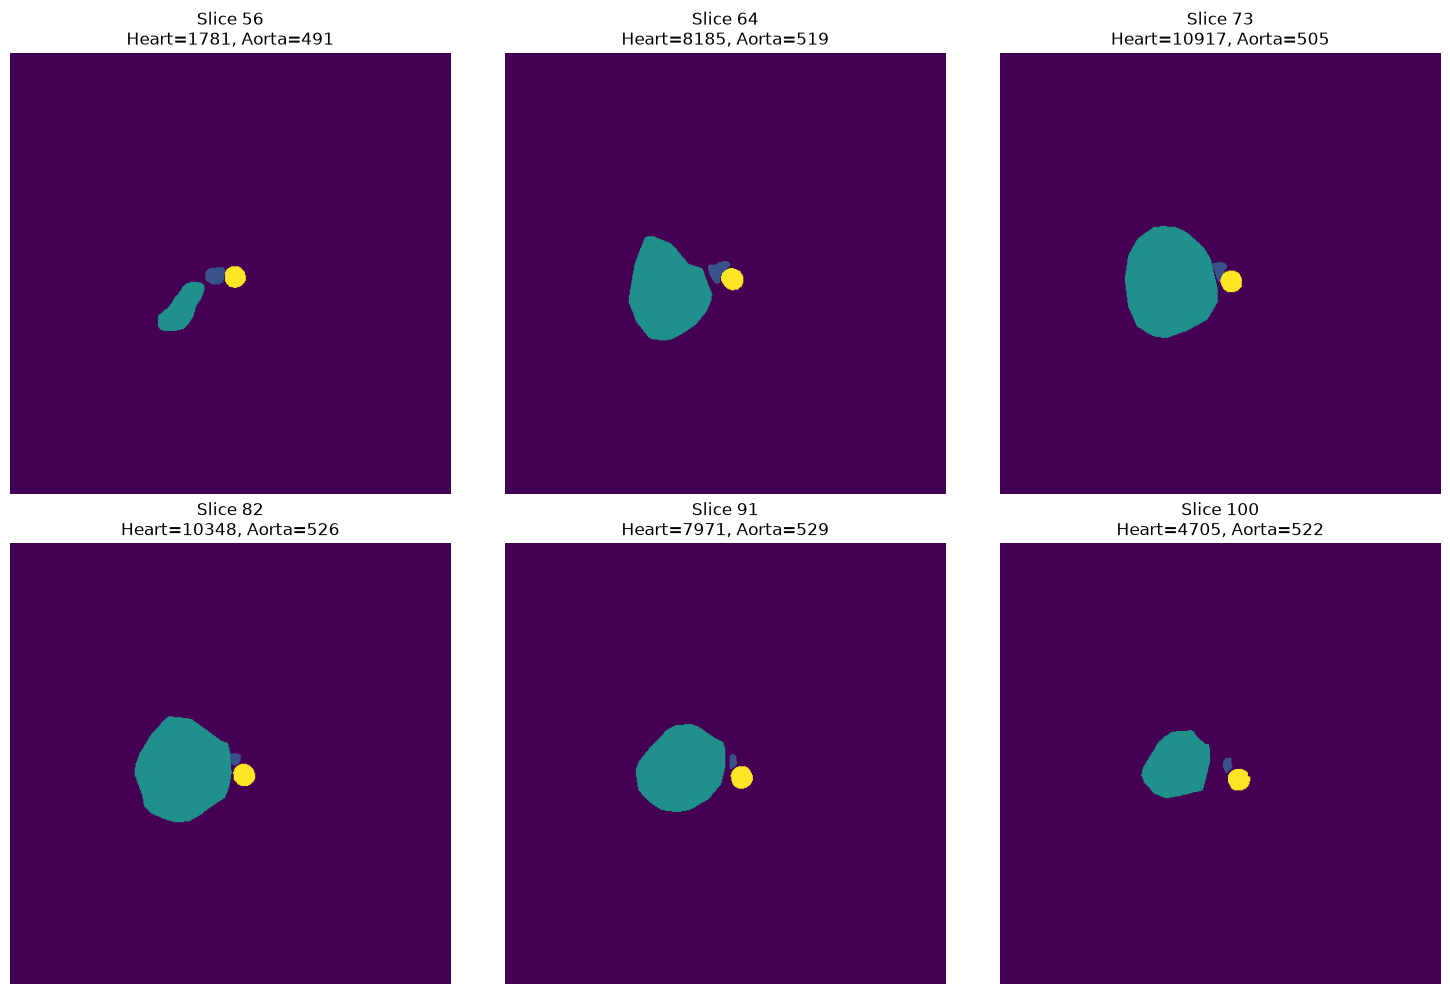

In [35]:
selected = candidate_slices[
    np.linspace(
        0,
        len(candidate_slices) - 1,
        min(6, len(candidate_slices))
    ).astype(int)
]

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 10)
)

for ax, z in zip(axes.flat, selected):

    ax.imshow(gt7[:, :, z])

    ax.set_title(
        f"Slice {z}\n"
        f"Heart={heart_area[z]:.0f}, "
        f"Aorta={aorta_area[z]:.0f}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [36]:
# Find the 10 slices with the largest heart areas
largest_heart = (
    area_df
    .sort_values("Heart", ascending=False)
    .head(10)
)

display(
    largest_heart[
        ["filename", "patient", "slice", "Heart"]
    ]
)

,filename,patient,slice,Heart
2509,Patient_18_0081.png,Patient_18,81,5229
2510,Patient_18_0082.png,Patient_18,82,5207
2508,Patient_18_0080.png,Patient_18,80,5190
2511,Patient_18_0083.png,Patient_18,83,5184
2503,Patient_18_0075.png,Patient_18,75,5182
2504,Patient_18_0076.png,Patient_18,76,5150
2512,Patient_18_0084.png,Patient_18,84,5150
2507,Patient_18_0079.png,Patient_18,79,5139
2505,Patient_18_0077.png,Patient_18,77,5129
2502,Patient_18_0074.png,Patient_18,74,5124


In [37]:
from skimage.measure import regionprops

shape_results = []

for gt_path in train_gt_paths + val_gt_paths:

    gt = np.array(Image.open(gt_path))
    mask = gt == 126

    labeled, n = label(mask)

    if n == 0:
        continue

    # There should be at most one heart component
    props = regionprops(labeled)

    largest = max(props, key=lambda x: x.area)

    shape_results.append({
        "filename": gt_path.name,
        "patient": gt_path.name.split("_")[0] + "_" + gt_path.name.split("_")[1],
        "slice": int(gt_path.stem.split("_")[-1]),
        "area": largest.area,
        "width": largest.bbox[3] - largest.bbox[1],
        "height": largest.bbox[2] - largest.bbox[0],
        "eccentricity": largest.eccentricity,
        "solidity": largest.solidity,
    })

shape_df = pd.DataFrame(shape_results)

display(shape_df.head())

,filename,patient,slice,area,width,height,eccentricity,solidity
0,Patient_02_0112.png,Patient_02,112,239.0,13,22,0.779131,0.967611
1,Patient_02_0113.png,Patient_02,113,333.0,19,26,0.680517,0.948718
2,Patient_02_0114.png,Patient_02,114,556.0,22,36,0.812978,0.958621
3,Patient_02_0115.png,Patient_02,115,1587.0,46,48,0.299995,0.971236
4,Patient_02_0116.png,Patient_02,116,1899.0,47,54,0.515545,0.977355
